# 08. 応用 — 確率・信号・金融

| 層 | セクション |
|---|---|
| Basic | 1. Big Picture 〜 5. Definition |
| Applied | 6. Computation 〜 9. Application |
| Advanced | 10. Exercises / 11. Advanced Notes |

> MGF とモーメント、割引現在価値(Gordon 成長と ROC)、待ち行列の入口で、$e^{-st}$ 重みの普遍性を見る。

In [1]:
# Shared setup: make laplace_book importable, fix seeds, inline + plotly rendering.
%matplotlib inline
import sys
from pathlib import Path

try:
    import laplace_book  # noqa: F401
except ModuleNotFoundError:
    for _base in (Path.cwd(), *Path.cwd().parents):
        if (_base / "src" / "laplace_book").is_dir():
            sys.path.insert(0, str(_base / "src"))
            break

import numpy as np
import matplotlib.pyplot as plt
import sympy as sp
from IPython.display import display

from laplace_book import transforms, systems, circuits, plotting, datasets, widgets, discrete
from laplace_book.transforms import t, s, L, Linv, numeric_laplace, partial_fractions

import plotly.io as pio
pio.renderers.default = "notebook_connected"

np.random.seed(0)
np.set_printoptions(precision=4, suppress=True)
sp.init_printing()

## 1. Big Picture

「$e^{-st}$ で重みづけて積分する」という同じ形が、確率・信号・金融に何度も現れます。本章はその接続を
直感的に示します(深入りはしません)。

## 2. 確率分布のラプラス変換 と モーメント母関数

非負確率変数 $X$ の密度 $f_X$ に対し $\varphi(s)=\mathbb{E}[e^{-sX}]=\int_0^\infty f_X(x)e^{-sx}dx$ は
まさにラプラス変換。モーメント母関数 $M_X(\theta)=\mathbb{E}[e^{\theta X}]=\varphi(-\theta)$ と表裏一体で、
$$ \mathbb{E}[X]=-\varphi'(0),\qquad \mathbb{E}[X^2]=\varphi''(0). $$
指数分布 $f_X=\lambda e^{-\lambda x}$ で確かめます。

In [2]:
lam = sp.symbols("lambda", positive=True)
phi = lam / (s + lam)                       # Laplace transform of the exponential pdf
display(phi)
EX = sp.simplify(-sp.diff(phi, s).subs(s, 0))
EX2 = sp.simplify(sp.diff(phi, s, 2).subs(s, 0))
print("E[X]  =", EX, "   (= 1/lambda)")
print("E[X^2]=", EX2, "   (= 2/lambda^2)")
print("Var   =", sp.simplify(EX2 - EX**2))

E[X]  = 1/lambda    (= 1/lambda)
E[X^2]= 2/lambda**2    (= 2/lambda^2)
Var   = lambda**(-2)


## 2b. 指数分布とそのモーメント (Applied)

指数分布 $\lambda e^{-\lambda x}$ の平均は $1/\lambda$。$\lambda$ を変えて密度と平均を描く。

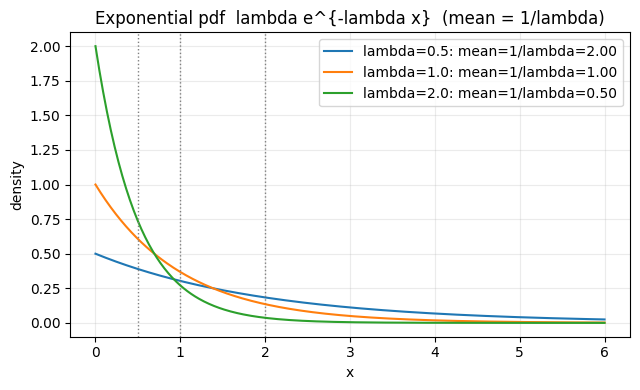

In [3]:
x = np.linspace(0, 6, 400)
fig, ax = plt.subplots(figsize=(6.5, 4))
for lam_v in [0.5, 1.0, 2.0]:
    ax.plot(x, lam_v * np.exp(-lam_v * x), label=f"lambda={lam_v}: mean=1/lambda={1 / lam_v:.2f}")
    ax.axvline(1 / lam_v, color="gray", ls=":", lw=1)
ax.set_title("Exponential pdf  lambda e^{-lambda x}  (mean = 1/lambda)")
ax.set_xlabel("x"); ax.set_ylabel("density"); ax.legend(); ax.grid(alpha=0.25)
plt.tight_layout()

## 3. 割引現在価値 (PV) — 金融の中のラプラス変換

連続割引の現在価値

$$ PV=\int_0^\infty c(t)\,e^{-rt}\,dt $$

は、キャッシュフロー $c(t)$ のラプラス変換を $s=r$ で評価したもの。一定 $c$ なら $PV=c/r$、
成長率 $g$ の $c(t)=c_0e^{gt}$ なら $PV=\dfrac{c_0}{r-g}$(**Gordon 成長モデル**)。
ここで収束条件 $r>g$ は、まさにラプラス変換の **収束域(ROC)** です。

In [4]:
r, g, c0 = 0.08, 0.03, 100.0
pv_numeric = numeric_laplace(lambda x: c0 * np.exp(g * x), r, t_max=400).real
print("PV numeric        :", pv_numeric)
print("PV analytic c0/(r-g):", c0 / (r - g))     # Gordon growth; requires r > g (the ROC)

PV numeric        : 1999.999995877693
PV analytic c0/(r-g): 2000.0


$r\le g$ だと積分が発散し、PV が定義できません。これは「ROC の外」と同じことで、
**割引率が成長率を上回らねばならない** という金融の常識が、収束域として自然に出てきます。

## 3b. PV は r → g で発散する (Applied)

成長率 $g$ を固定して割引率 $r$ を動かすと、$PV=c_0/(r-g)$ は $r\to g^+$ で発散する。
発散の境界 $r=g$ が、ちょうどラプラス変換の **収束域(ROC)の縁** にあたる。

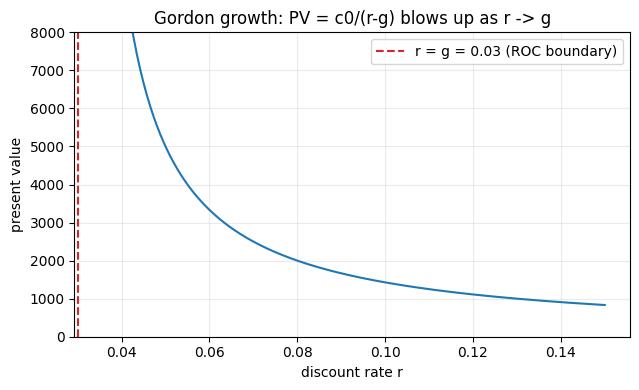

In [5]:
g_fixed, c0v = 0.03, 100.0
r_vals = np.linspace(0.035, 0.15, 300)
fig, ax = plt.subplots(figsize=(6.5, 4))
ax.plot(r_vals, c0v / (r_vals - g_fixed), color=plotting.ACCENT)
ax.axvline(g_fixed, color="#d62728", ls="--", label=f"r = g = {g_fixed} (ROC boundary)")
ax.set_ylim(0, 8000)
ax.set_title("Gordon growth: PV = c0/(r-g) blows up as r -> g")
ax.set_xlabel("discount rate r"); ax.set_ylabel("present value"); ax.legend(); ax.grid(alpha=0.25)
plt.tight_layout()

## 4. 信号処理 / 待ち行列の入口

- **信号処理**: フィルタは畳み込み = $s$ での積(05 章)。連続系は $s$、離散系は $z$ 変換へ拡張。
- **待ち行列**: M/M/1 などの待ち時間分布は **ラプラス-スティルチェス変換** で解析される(本書では入口のみ)。

## 5. Failure Mode / 注意点

- 金融でのラプラス変換は **万能な予測器ではない**。割引・現在価値・待ち時間分布との接続を整理する道具。
- 確率過程・SDE は入口だけ。深入りは専門書へ。

## 6. Exercises / Advanced & TODO

- **Basic**: 一定キャッシュフロー $c$ の永久債 $PV=c/r$ を積分で確かめよ。
- **Applied**: ガンマ分布 $f_X=\frac{\lambda^k x^{k-1}e^{-\lambda x}}{(k-1)!}$ のラプラス変換 $\big(\frac{\lambda}{s+\lambda}\big)^k$ を導け。
- **Advanced**: 合成分布(独立和)のラプラス変換が積になることを、畳み込み定理(05 章)から説明せよ。

> **TODO(今後の拡張)**: ラプラス-スティルチェス変換と M/M/1 待ち時間、複利・債券価格の期間構造、
> 特性関数(フーリエ)との対応、SDE の生成作用素との関係を追加。